# Task 4 - Sentiment Analysis

**Objective:** Build a machine learning model that classifies the sentiment of text data (positive or negative), providing insights into public opinion.

**Dataset:** IMDB Dataset of 50K Movie Reviews (Kaggle)

**Tools:** Python, pandas, scikit-learn, NLTK, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("Dataset/IMDB Dataset.csv")
print("Shape:", df.shape)
print("\nSentiment class distribution:")
print(df["sentiment"].value_counts())
df.head()

Shape: (50000, 2)

Sentiment class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Load Dataset and Inspect Class Distribution

**Observation:** The dataset contains 50,000 reviews, perfectly balanced between positive and negative sentiment (25,000 each). This balance means we don't need special techniques for class imbalance — accuracy will be a meaningful metric here, unlike in imbalanced problems. The raw text also contains HTML artifacts (e.g. `<br />` tags) that must be removed during preprocessing.

### Text Preprocessing Pipeline

Cleaning steps: lowercase conversion, HTML tag removal, punctuation removal, stopword removal, and tokenization.

In [2]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra whitespace
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return " ".join(words)

df["cleaned_review"] = df["review"].apply(preprocess_text)

df[["review", "cleaned_review"]].head(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pujak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...


**Result:** The cleaned text retains only meaningful lowercase words — HTML tags, punctuation, and common stopwords ("of", "the", "has") have been removed. This reduces noise before feature extraction.

### Feature Extraction: TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features by scoring each word based on how frequently it appears in a review relative to how common it is across all reviews. Words that appear often in one review but rarely elsewhere get higher scores — these are usually the most informative words for classification. We limit to the top 5,000 features to keep training fast and avoid overfitting to rare words.

In [3]:
X = df["cleaned_review"]
y = df["sentiment"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Test set size:", X_test_tfidf.shape)

Training set size: (40000, 5000)
Test set size: (10000, 5000)


### Train Classifiers: Naive Bayes and Logistic Regression

In [4]:
# Model 1: Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("Both models trained successfully.")

Both models trained successfully.


### Model Evaluation

In [5]:
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, pos_label="positive"))
    print("Recall:", recall_score(y_true, y_pred, pos_label="positive"))
    print("F1 Score:", f1_score(y_true, y_pred, pos_label="positive"))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\n")

evaluate_model("Naive Bayes", y_test, nb_preds)
evaluate_model("Logistic Regression", y_test, lr_preds)

--- Naive Bayes ---
Accuracy: 0.8573
Precision: 0.8511893060743071
Recall: 0.866
F1 Score: 0.8585307821949043

Classification Report:
               precision    recall  f1-score   support

    negative       0.86      0.85      0.86      5000
    positive       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



--- Logistic Regression ---
Accuracy: 0.8936
Precision: 0.8877068557919622
Recall: 0.9012
F1 Score: 0.8944025406907503

Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.89      0.89      5000
    positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000





**Observation:** Logistic Regression outperforms Naive Bayes across every metric — 89.4% accuracy vs 85.7%, and similarly higher precision, recall, and F1-score. This is a common result in text classification: Naive Bayes assumes word features are independent given the class, which is rarely true in real language (word order and co-occurrence matter), while Logistic Regression can better capture the combined weight of many correlated features. Both models perform respectably given they only use simple TF-IDF features with no deep learning, but Logistic Regression is the stronger choice here.

### Confusion Matrices

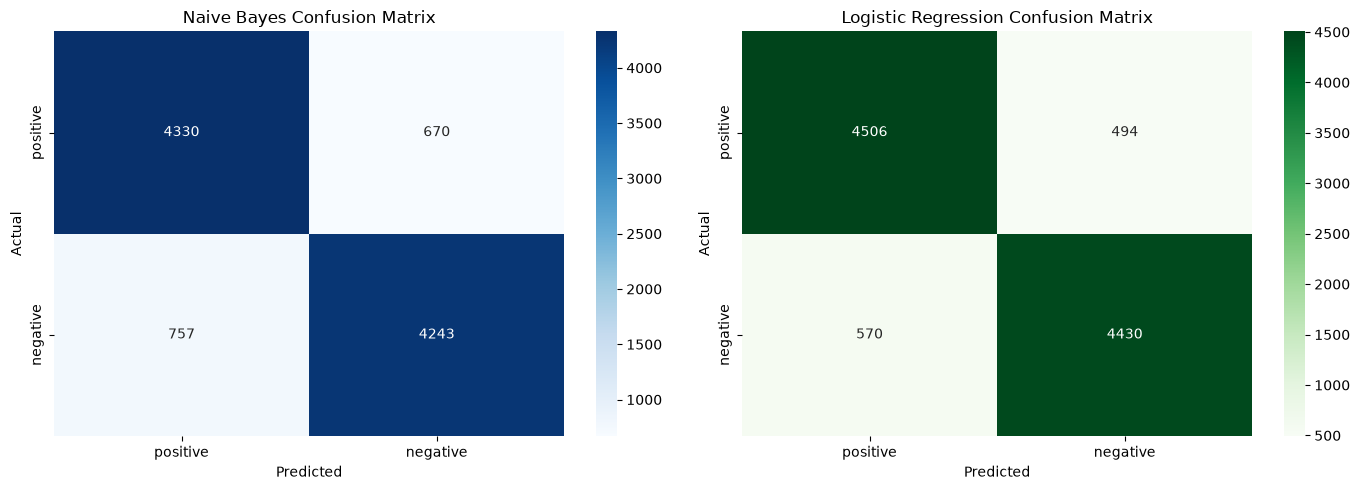

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_nb = confusion_matrix(y_test, nb_preds, labels=["positive", "negative"])
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["positive", "negative"], yticklabels=["positive", "negative"])
axes[0].set_title("Naive Bayes Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_lr = confusion_matrix(y_test, lr_preds, labels=["positive", "negative"])
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["positive", "negative"], yticklabels=["positive", "negative"])
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("Images/confusion_matrices.png", dpi=150)
plt.show()

**Observation:** Both models show fairly balanced error patterns — no strong bias toward either class. Logistic Regression makes fewer total errors (494 + 570 = 1,064) than Naive Bayes (670 + 757 = 1,427), consistent with its higher accuracy. Naive Bayes leans slightly toward false negatives (misclassifying negative reviews as positive more often, 757 vs 670), while Logistic Regression is more balanced between the two error types.

### Sentiment Distribution in the Dataset

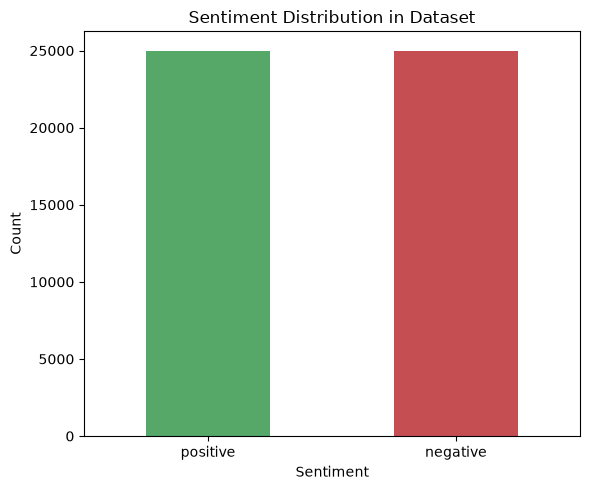

In [7]:
plt.figure(figsize=(6, 5))
df["sentiment"].value_counts().plot(kind="bar", color=["#55A868", "#C44E52"])
plt.title("Sentiment Distribution in Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/sentiment_distribution.png", dpi=150)
plt.show()

### Error Analysis: Misclassified Examples (Logistic Regression)

In [8]:
results = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": lr_preds
})

misclassified = results[results["actual"] != results["predicted"]]

pd.set_option('display.max_colwidth', 200)
misclassified.sample(5, random_state=42)

,review,actual,predicted
306,movie great way series finally end peter boy puppet master iii grown puppet master well girl comes destroy puppets learn toulon secrets instead listens story puppets movie footage puppet master ii...,positive,negative
9908,pleasantly surprised film let face premise sound particularly appealing hand money night flick easygoing nature wins one moments found uproarious doubt remember next day fail nice diversion found ...,positive,negative
3851,spent last week watching john cassavetes films starting woman influence ending opening night completely utterly blown away particular two films first minute last opening night completely utterly a...,positive,negative
7039,orson welles documentary f fake examines trickery fraud mainly focusing two men exposed frauds clifford irving biographer wrote allegedly fraudulent howard hughes autobiography yet least seems pur...,negative,positive
7537,putney swope unique low low low budget gem late probably would forgotten time two things paul thomas anderson named cheadle character boogie nights buck swope eponymous hero film limited dvd relea...,positive,negative


### Discussion: Why the Model Misclassified These Reviews

1. **Row 306** — Discusses puppet/horror movie plot events ("destroy puppets," "secrets") in a positive review. The model likely picked up on ominous-sounding plot vocabulary and misread it as negative sentiment, when it was actually neutral plot description.

2. **Row 9908** — Contains genuinely mixed language ("pleasantly surprised... appealing" alongside "fail... uproarious doubt"). TF-IDF treats words independently, so it can't tell that "fail" here refers to a plot element or minor flaw rather than an overall negative judgment.

3. **Row 3851** — A long, detailed review ("completely utterly blown away") that is clearly enthusiastic to a human reader, but the model may be diluted by the sheer length and variety of vocabulary, reducing the influence of the strongly positive phrases.

4. **Row 7039** — About a documentary examining "trickery," "fraud," and "fraudulent" claims — the actual review is *negative*, but was predicted *positive*. This is a case where subject-matter vocabulary (about deception) overlaps with words that might otherwise skew neutral or even positive in other contexts, confusing the model in the opposite direction.

5. **Row 7537** — Describes a "low low low budget gem" — actually positive despite repeated negative-sounding words ("low," "forgotten"), which the model likely weighted too heavily as negative signals.

**Common pattern:** All 5 errors involve either (a) sentiment-neutral or plot-descriptive language containing emotionally-loaded words, or (b) genuinely mixed sentiment within a single review. This is a well-known limitation of TF-IDF + traditional classifiers — they lack the ability to understand context, negation scope, and sarcasm the way a human reader (or a more advanced model like BERT) can.

## Conclusion

**Best performing model:** Logistic Regression, with 89.4% accuracy compared to Naive Bayes' 85.7%. It also showed more balanced error rates between false positives and false negatives.

**Real-world application:** This kind of sentiment classifier could be deployed by a streaming platform or review aggregator to automatically flag review sentiment at scale — for example, tracking overall audience reception of a new movie release in real time, or routing strongly negative reviews to a customer support/moderation team for review, without needing every review read manually.

**Limitations:** As the error analysis showed, both models struggle with sarcasm, mixed sentiment within a single review, and emotionally-loaded vocabulary used in a neutral or contrary context. A production system would benefit from more advanced techniques (e.g. word embeddings or transformer-based models like BERT) to better capture context and word order, which simple TF-IDF cannot.